## __Data Science: Capstone Part 2: Lightning Talk 2__

### Overview

On the **One** topic you have selected you would need to:
1. Refine your problem statement. for more info [ML-Framing-a-Data-Science-Problem]() **<--- will cover on Tuesday**
2. Create / Compile a data dictionary
3. Clean the data and Perform in-depth EDA (Insights + EDA for Modeling)
4. Outline proposed preprocessing/feature engineering and models

### Presentation Requirements (5 Minutes)
* Refined Problem Statement  (including Success Metrics)
* Potential Audience
* Goals & Objectives
    * Type of Models (e.g: Regression/Classification)
    * Number of models
    * Evaluation Metrics
* About the data (Data Dictionary and EDA for Modeling) - Keep this short 
* Progress report (Challenges & Next Steps)



___Note: EDA for Image based Topics___
* Classes (Target)
* Settings (Transformation)
* Data Limitations


# Bank Customer Churn Data
Data Source : https://www.kaggle.com/datasets/pentakrishnakishore/bank-customer-churn-data?select=churn_prediction.csv

# Problem Statement

A retail bank makes most of its money from the deposits sitting in its customers' savings
accounts. Right now 18.53% of customers churn, they let their balance fall below the
required minimum and go dormant. The bank only finds out after the money has already
left. Meanwhile the retention team calls customers almost at random, wasting effort on
people who were never going to leave, while missing the ones who actually do.

We aim to classify existing savings-account customers as "high risk" or "low risk" of
churning, using their demographics, branch information and recent transaction behaviour
(balances, credits and debits over the last months). This will allow
the retention team to contact only the at-risk customers with targeted offers, with the
goal of catching at least 70% of real churners (recall >= 0.70) (Of the real churners, how many did we catch?) while keeping the
contact list small enough to be actionable.

**Success Metrics**

| Metric | Target | Why this metric |
| --- | --- | --- |
| **Recall (churn class)** | **>= 0.70** | The main business metric. A missed churner is lost deposits; a wasted phone call is cheap. |
| **ROC-AUC** | **>= 0.80** | Measures ranking ability across all thresholds, and is not fooled by the 81/19 imbalance. |
| **Precision / F1** | monitored | Keeps the contact list realistic, we do not want to flag everyone. |

**Potential Audience**
- **Retention / CRM team** — receives the ranked list of at-risk customers to call.
- **Branch managers** — see which branches and customer segments lose the most deposits.
- **Risk & Finance** — quantify deposits at risk.
- **Data science team** — maintains and retrains the model.

## Objectives
List the key questions guiding your analysis and modeling:

1. **Who churns?** Do churners differ from non-churners in age, occupation, net-worth
   category or how long they have been with the bank ('vintage')?
2. **Does money movement predict churn?** Is a falling balance, or a drop in credits and
   debits between months, a warning sign?
3. **Which features carry signal?** The strongest single correlation
   with 'churn' was only 0.073. Can engineered features (balance change, net cash
   flow, dormancy) do better than the raw columns?
4. **What has to be cleaned first?** How do we handle the hidden nulls, the impossible
   ages and the extreme skew in the money columns — without deleting the high-value
   customers the model exists to protect?
5. **How will we handle the 81/19 imbalance** so the model finds churners instead of
   playing it safe?

# Data Inspection

## Data Dictionary
*As Mr. Jubran Asked, the dictionary is after cleaning...


### Customer information

| Column | Type | Description |
| --- | --- | --- |
| `vintage` | int | Number of days the customer has been with the bank |
| `age` | float | Age of the customer. **Cleaned** — 806 impossible values (< 18) replaced with the median (46) |
| `gender` | object | Male / Female / **`unknown`** (525 imputed) |
| `dependents` | float | Number of people the customer financially supports. **Cleaned** — 2,463 nulls filled with the mode (0); **capped at 6** (10 impossible values up to 52) |
| `occupation` | object | self_employed, salaried, student, retired, company. **Cleaned** — 80 nulls filled with the mode |
| `customer_nw_category` | int | The bank's internal net-worth tier (1, 2 or 3) |

### Location

| Column | Type | Description |
| --- | --- | --- |
| `city` | float | City code. **Cleaned** — 803 nulls filled with `-1`. **High cardinality (1,605 codes)** — needs encoding |
| `branch_code` | int | Branch code. **High cardinality (3,185 codes)** — needs encoding |

### Account balances

| Column | Type | Description |
| --- | --- | --- |
| `current_balance` | float | Current account balance. Negative values are genuine overdrafts |
| `previous_month_end_balance` | float | Balance at the end of last month |
| `average_monthly_balance_prevQ` | float | Average monthly balance, previous quarter |
| `average_monthly_balance_prevQ2` | float | Average monthly balance, the quarter before that |
| `current_month_balance` | float | Average balance this month |
| `previous_month_balance` | float | Average balance last month |

These six correlate with each other up to **0.994**, most will be dropped in
preprocessing and replaced by change-based features.

### Transaction activity

| Column | Type | Description |
| --- | --- | --- |
| `current_month_credit` | float | Money paid **in** this month |
| `previous_month_credit` | float | Money paid **in** last month |
| `current_month_debit` | float | Money taken **out** this month — **strongest single signal** (churner median 1,120 vs 22) |
| `previous_month_debit` | float | Money taken **out** last month (churner median 838 vs 43) |

### Engineered features (created)

| Column | Type | Description |
| --- | --- | --- |
| `no_last_txn` | int | **NEW** — 1 if the customer had no recorded last transaction (was hidden as the text `'NaT'`). Churn 9.28% vs 19.72% |
| `days_since_txn` | float | **NEW** — days between the customer's last transaction and the end of the data window (2019-12-31). Null for the 3,223 customers with no transaction |

### Target

| Column | Type | Description |
| --- | --- | --- |
| **`churn`** | int | **TARGET** — 1 = customer churned (5,260, **18.53%**), 0 = stayed (23,122, 81.47%) |

### Removed during cleaning

| Column | Reason |
| --- | --- |
| `customer_id` | Identifier — 28,382 unique values, no predictive information |
| `last_transaction` | Raw date replaced by `no_last_txn` and `days_since_txn` |

In [51]:
# organize your imports in this cell
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings('ignore')

## Data Overview
Load and inspect the dataset
- Source and format
- .head(), .info(), .describe(),…

**Source and format**

| | |
| --- | --- |
| Source | Kaggle — Bank Customer Churn Data |
| Format | CSV file |
| Rows | 28,382 customers |
| Columns | 21 |
| Target | 'churn' (1 = churned, 0 = stayed) |
| Problem type | Classification |

In [52]:
df = pd.read_csv('./data/churn_prediction.csv')
df.head()

,customer_id,vintage,age,gender,dependents,occupation,city,customer_nw_category,branch_code,current_balance,previous_month_end_balance,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn,last_transaction
0,1,2101,66,Male,0.0,self_employed,187.0,2,755,1458.71,1458.71,1458.71,1449.07,0.20,0.20,0.20,0.20,1458.71,1458.71,0,2019-05-21
1,2,2348,35,Male,0.0,self_employed,NaN,2,3214,5390.37,8704.66,7799.26,12419.41,0.56,0.56,5486.27,100.56,6496.78,8787.61,0,2019-11-01
2,4,2194,31,Male,0.0,salaried,146.0,2,41,3913.16,5815.29,4910.17,2815.94,0.61,0.61,6046.73,259.23,5006.28,5070.14,0,NaT
3,5,2329,90,NaN,NaN,self_employed,1020.0,2,582,2291.91,2291.91,2084.54,1006.54,0.47,0.47,0.47,2143.33,2291.91,1669.79,1,2019-08-06
4,6,1579,42,Male,2.0,self_employed,1494.0,3,388,927.72,1401.72,1643.31,1871.12,0.33,714.61,588.62,1538.06,1157.15,1677.16,1,2019-11-03


In [53]:
df.shape

(28382, 21)

In [54]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 28382 entries, 0 to 28381
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   customer_id                     28382 non-null  int64  
 1   vintage                         28382 non-null  int64  
 2   age                             28382 non-null  int64  
 3   gender                          27857 non-null  str    
 4   dependents                      25919 non-null  float64
 5   occupation                      28302 non-null  str    
 6   city                            27579 non-null  float64
 7   customer_nw_category            28382 non-null  int64  
 8   branch_code                     28382 non-null  int64  
 9   current_balance                 28382 non-null  float64
 10  previous_month_end_balance      28382 non-null  float64
 11  average_monthly_balance_prevQ   28382 non-null  float64
 12  average_monthly_balance_prevQ2  28382 non-n

In [55]:
df.isnull().sum()

customer_id                          0
vintage                              0
age                                  0
gender                             525
dependents                        2463
occupation                          80
city                               803
customer_nw_category                 0
branch_code                          0
current_balance                      0
previous_month_end_balance           0
average_monthly_balance_prevQ        0
average_monthly_balance_prevQ2       0
current_month_credit                 0
previous_month_credit                0
current_month_debit                  0
previous_month_debit                 0
current_month_balance                0
previous_month_balance               0
churn                                0
last_transaction                     0
dtype: int64

In [56]:
df.describe()

,customer_id,vintage,age,dependents,city,customer_nw_category,branch_code,current_balance,previous_month_end_balance,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn
count,28382.000000,28382.000000,28382.000000,25919.000000,27579.000000,28382.000000,28382.000000,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,28382.000000
mean,15143.508667,2091.144105,48.208336,0.347236,796.109576,2.225530,925.975019,7.380552e+03,7.495771e+03,7.496780e+03,7.124209e+03,3.433252e+03,3.261694e+03,3.658745e+03,3.339761e+03,7.451133e+03,7.495177e+03,0.185329
std,8746.454456,272.676775,17.807163,0.997661,432.872102,0.660443,937.799129,4.259871e+04,4.252935e+04,4.172622e+04,4.457581e+04,7.707145e+04,2.968889e+04,5.198542e+04,2.430111e+04,4.203394e+04,4.243198e+04,0.388571
min,1.000000,73.000000,1.000000,0.000000,0.000000,1.000000,1.000000,-5.503960e+03,-3.149570e+03,1.428690e+03,-1.650610e+04,1.000000e-02,1.000000e-02,1.000000e-02,1.000000e-02,-3.374180e+03,-5.171920e+03,0.000000
25%,7557.250000,1958.000000,36.000000,0.000000,409.000000,2.000000,176.000000,1.784470e+03,1.906000e+03,2.180945e+03,1.832507e+03,3.100000e-01,3.300000e-01,4.100000e-01,4.100000e-01,1.996765e+03,2.074407e+03,0.000000
50%,15150.500000,2154.000000,46.000000,0.000000,834.000000,2.000000,572.000000,3.281255e+03,3.379915e+03,3.542865e+03,3.359600e+03,6.100000e-01,6.300000e-01,9.193000e+01,1.099600e+02,3.447995e+03,3.465235e+03,0.000000
75%,22706.750000,2292.000000,60.000000,0.000000,1096.000000,3.000000,1440.000000,6.635820e+03,6.656535e+03,6.666887e+03,6.517960e+03,7.072725e+02,7.492350e+02,1.360435e+03,1.357553e+03,6.667958e+03,6.654693e+03,0.000000
max,30301.000000,2476.000000,90.000000,52.000000,1649.000000,3.000000,4782.000000,5.905904e+06,5.740439e+06,5.700290e+06,5.010170e+06,1.226985e+07,2.361808e+06,7.637857e+06,1.414168e+06,5.778185e+06,5.720144e+06,1.000000


In [57]:
# age has a minimum of 1. A one-year-old cannot hold a savings account, so this is a data-entry error, not a real customer.

# dependents has a maximum of 52. Also not believable.

# The money columns are extremely skewed. current_balance has a median of 3,281 but a maximum of 5,905,904.
# The mean (7,380) sitting far above the median, long right tail. current_month_credit is worse: median 0.61, maximum 12,269,845.

# 'current_balance' has a minimum of -5,503. Negative balances are real overdrafts, not errors, so these stay.

In [58]:
df.duplicated().sum()

np.int64(0)

In [59]:
df['churn'].value_counts()

churn
0    23122
1     5260
Name: count, dtype: int64

In [60]:
df['churn'].value_counts(normalize=True) * 100

churn
0    81.467127
1    18.532873
Name: proportion, dtype: float64

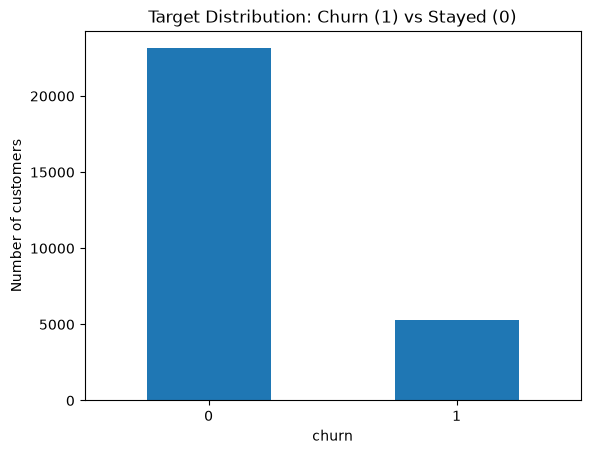

In [61]:
# imbalance of thre target
df['churn'].value_counts().plot(kind='bar',title='Target Distribution: Churn (1) vs Stayed (0)',rot=0)
plt.xlabel('churn')
plt.ylabel('Number of customers')
plt.show()

In [62]:
# The target is imbalanced
# it decides our metrics (recall and ROC-AUC, never accuracy),
# and our train/test split (stratify=y) and our modelling strategy (class_weight='balanced' and resampling).

# Data Cleaning
Handle missing values, outliers, and inconsistencies

In banking, the extreme values are the high-value customers, the exact people the model exists to protect. Deleting them would remove the point of the project.

In [63]:
clean_df = df.copy()

clean_df = clean_df.drop(columns=['customer_id'])
clean_df.shape

(28382, 20)

In [64]:
clean_df['last_transaction'].isnull().sum()

np.int64(0)

In [65]:
# '.isnull()' reports zero nulls in this column. That is wrong. The missing dates were,
# saved as the text 'NaT', so pandas reads them as an ordinary string.
(clean_df['last_transaction'] == 'NaT').sum()

np.int64(3223)

In [66]:
# Is this missingness informative? Compare churn rates.
print('has a date :', clean_df.loc[clean_df.last_transaction != 'NaT', 'churn'].mean()*100, '%')
print('no date:', clean_df.loc[clean_df.last_transaction == 'NaT', 'churn'].mean()*100, '%')

has a date : 19.71858976906872 %
no date: 9.27707105181508 %


In [67]:
# the missingness is not random

# Customers with a last-transaction date churn at 19.71%
# Customers without one, churn at only 9.27%

# so a missing date is not noise, it is a signal worth keeping. 
# We turn it into two features instead of throwing the rows away.

In [68]:
# does this customer have a recorded last transaction?
clean_df['no_last_txn'] = (clean_df['last_transaction'] == 'NaT').astype(int)

# lets convert to a real date.
clean_df['last_transaction'] = pd.to_datetime(clean_df['last_transaction'], errors='coerce')

print('date range:', clean_df['last_transaction'].min(), 'to', clean_df['last_transaction'].max())
print('real nulls now:', clean_df['last_transaction'].isnull().sum())

date range: 2018-12-31 00:00:00 to 2019-12-31 00:00:00
real nulls now: 3223


In [69]:
# how many days before the end of the data window did they last transact?
# The data ends 2019-12-31, so we measure backwards from there.
clean_df['days_since_txn'] = (pd.Timestamp('2019-12-31') - clean_df['last_transaction']).dt.days

# the raw date column is no longer needed
clean_df = clean_df.drop(columns=['last_transaction'])

clean_df[['no_last_txn', 'days_since_txn']].tail()

,no_last_txn,days_since_txn
28377,0,70.0
28378,0,14.0
28379,0,0.0
28380,1,NaN
28381,0,59.0


In [70]:
print('customers under 18 :', (clean_df['age'] < 18).sum())
print('youngest customer  :', clean_df['age'].min())
print('median age         :', clean_df['age'].median())

customers under 18 : 806
youngest customer  : 1
median age         : 46.0


In [73]:
# A one year old cannot hold a savings account.
# lets treat impossible ages as missing, then fill with the median (46).
clean_df.loc[clean_df['age'] < 18, 'age'] = np.nan
clean_df['age'] = clean_df['age'].fillna(clean_df['age'].median())

In [74]:
# 'dependents' = the number of people the customer financially supports
# (children, elderly parents, a non-working spouse).
clean_df['dependents'].value_counts().sort_index()

dependents
0.0     21435
1.0      1395
2.0      2150
3.0       701
4.0       179
5.0        41
6.0         8
7.0         3
8.0         1
9.0         1
25.0        1
32.0        1
36.0        1
50.0        1
52.0        1
Name: count, dtype: int64

In [75]:
# cap the 10 impossible values at 6
clean_df['dependents'] = clean_df['dependents'].clip(upper=6)

print('new maximum:', clean_df['dependents'].max())

new maximum: 6.0


In [79]:
# if customers with a missing value churn at a very different rate, the missingness itself is a signal.
# lets compare churn rate for missing vs non-missing, for each column with nulls
for col in ['gender', 'dependents', 'occupation', 'city']:
    is_null = df[col].isna()
    print(f'{col} missing: {df.loc[is_null, "churn"].mean()*100}%  present: {df.loc[~is_null, "churn"].mean()*100}%  (n missing = {is_null.sum()})')

gender missing: 20.19047619047619%  present: 18.501633341709443%  (n missing = 525)
dependents missing: 21.39667072675599%  present: 18.260735367876848%  (n missing = 2463)
occupation missing: 16.25%  present: 18.53932584269663%  (n missing = 80)
city missing: 20.298879202988793%  present: 18.481453279669314%  (n missing = 803)


In [83]:
# the differences are small, so the missingness here is not strongly informative

| Column | Missing | Decision | Why |
| --- | --- | --- | --- |
| `dependents` | 2,463 | fill with mode (0) | most of customers have 0|
| `city` | 803 | fill with -1 as its own category | We must not guess where someone lives |
| `gender` | 525 | fill with 'unknown' as a 3rd category | Better than forcing people into Male/Female |
| `occupation` | 80 | fill with mode | 80 nulls are too small to affect anything |

In [82]:
# No rows are dropped, dropping every row with any null woul throw away thousands of usable customers.
clean_df['dependents'] = clean_df['dependents'].fillna(clean_df['dependents'].mode()[0])
clean_df['gender']     = clean_df['gender'].fillna('unknown')
clean_df['occupation'] = clean_df['occupation'].fillna(clean_df['occupation'].mode()[0])
clean_df['city']       = clean_df['city'].fillna(-1)

# confirm nothing is left
clean_df.isnull().sum()

vintage                              0
age                                  0
gender                               0
dependents                           0
occupation                           0
city                                 0
customer_nw_category                 0
branch_code                          0
current_balance                      0
previous_month_end_balance           0
average_monthly_balance_prevQ        0
average_monthly_balance_prevQ2       0
current_month_credit                 0
previous_month_credit                0
current_month_debit                  0
previous_month_debit                 0
current_month_balance                0
previous_month_balance               0
churn                                0
no_last_txn                          0
days_since_txn                    3223
dtype: int64

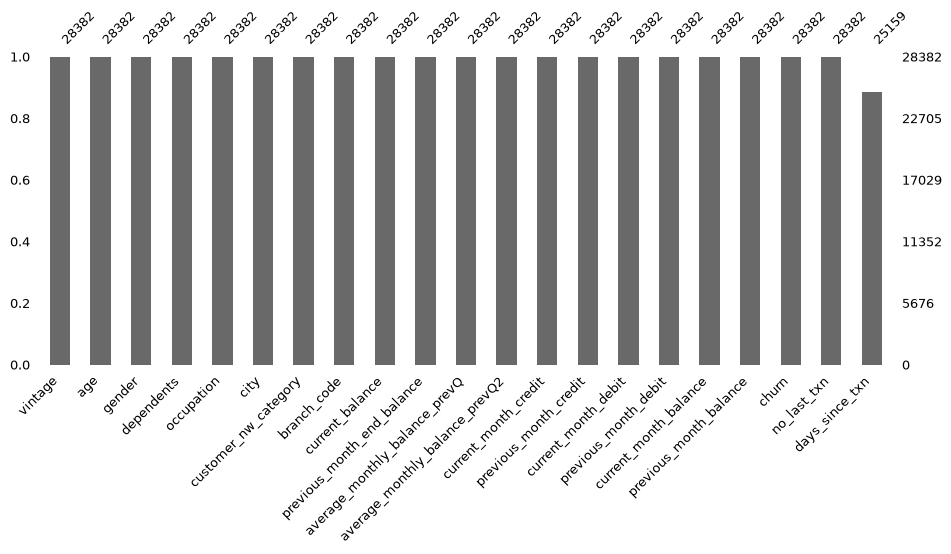

In [84]:
# visual confirmation that the dataset is now complete
msno.bar(clean_df, figsize=(11, 4), fontsize=9)
plt.show()

In [90]:
clean_df.dtypes

vintage                             int64
age                               float64
gender                                str
dependents                        float64
occupation                            str
city                              float64
customer_nw_category                int64
branch_code                         int64
current_balance                   float64
previous_month_end_balance        float64
average_monthly_balance_prevQ     float64
average_monthly_balance_prevQ2    float64
current_month_credit              float64
previous_month_credit             float64
current_month_debit               float64
previous_month_debit              float64
current_month_balance             float64
previous_month_balance            float64
churn                               int64
no_last_txn                         int64
days_since_txn                    float64
dtype: object

In [88]:
for col in ['city', 'branch_code']:
    print(f'{col} unique codes: {clean_df[col].nunique()}')

city unique codes: 1605
branch_code unique codes: 3185


city (1,604 codes) and branch_code (3,185 codes) are stored as numbers but they are
location codes, not quantities, branch 3000 is not "bigger" than branch 100.

One-hot encoding them would create many new columns. I mention them here and deal
with them in the Preprocessing section.

In [91]:
print('before:', df.shape, ' after:', clean_df.shape)
print('nulls remaining:', clean_df.isnull().sum().sum())
print('duplicates:', clean_df.duplicated().sum())

before: (28382, 21)  after: (28382, 21)
nulls remaining: 3223
duplicates: 0


# Exploratory Data Analysis (EDA)
Answer objectives using visual and statistical insights
- Trends, relationships, anomalies
- Outlier and missing values treatment
- Univariate, bivariate, or multivariate analysis
    - Histograms, box plots, bar charts
    - Correlation matrix for continuous columns (required if applicable)


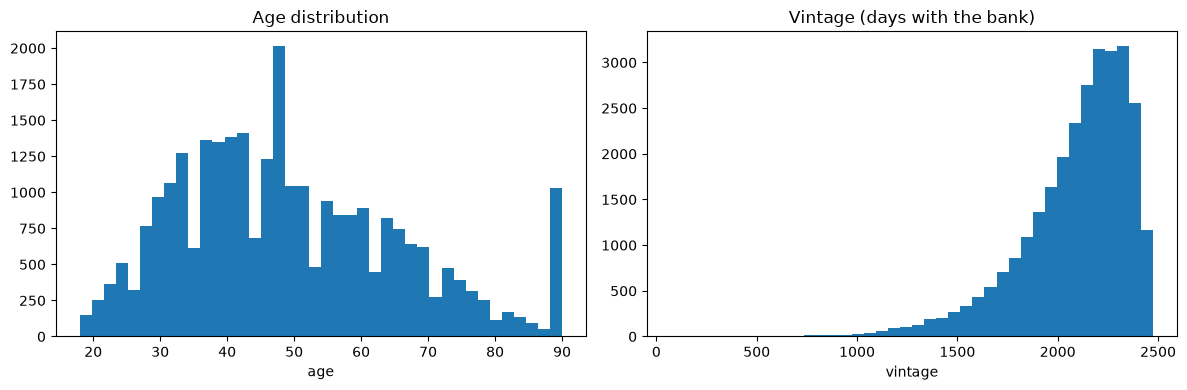

In [92]:
# how old are the customers, and how long have they been with the bank?
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

clean_df['age'].hist(grid=False, bins=40, ax=axes[0])
axes[0].set_title('Age distribution')
axes[0].set_xlabel('age')

clean_df['vintage'].hist(grid=False, bins=40, ax=axes[1])
axes[1].set_title('Vintage (days with the bank)')
axes[1].set_xlabel('vintage')

plt.tight_layout()
plt.show()

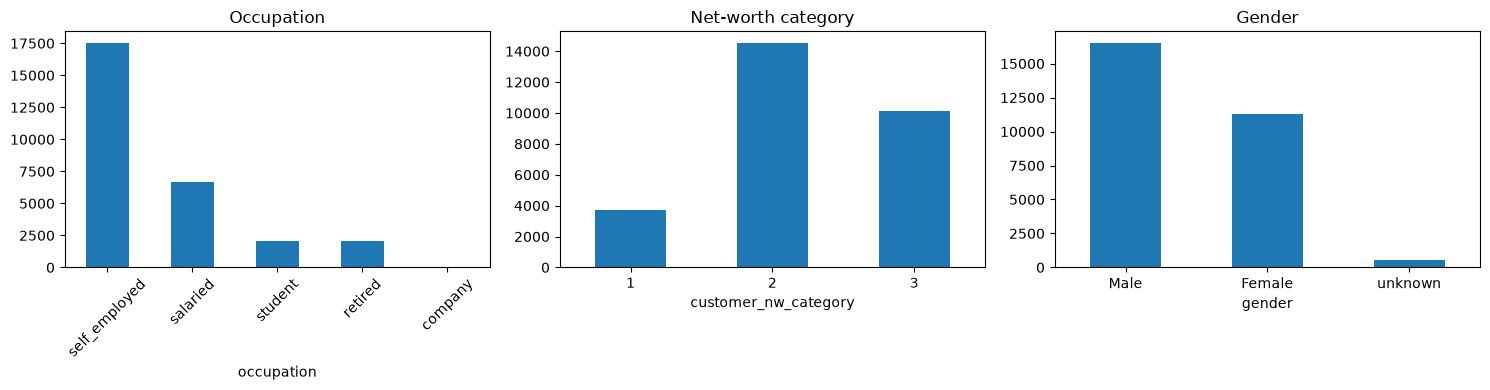

In [94]:
# what kind of customers does this bank have?
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

clean_df['occupation'].value_counts().plot(kind='bar', ax=axes[0], rot=45, title='Occupation')
clean_df['customer_nw_category'].value_counts().sort_index().plot(kind='bar', ax=axes[1], rot=0,
                                                                  title='Net-worth category')
clean_df['gender'].value_counts().plot(kind='bar', ax=axes[2], rot=0, title='Gender')

plt.tight_layout()
plt.show()

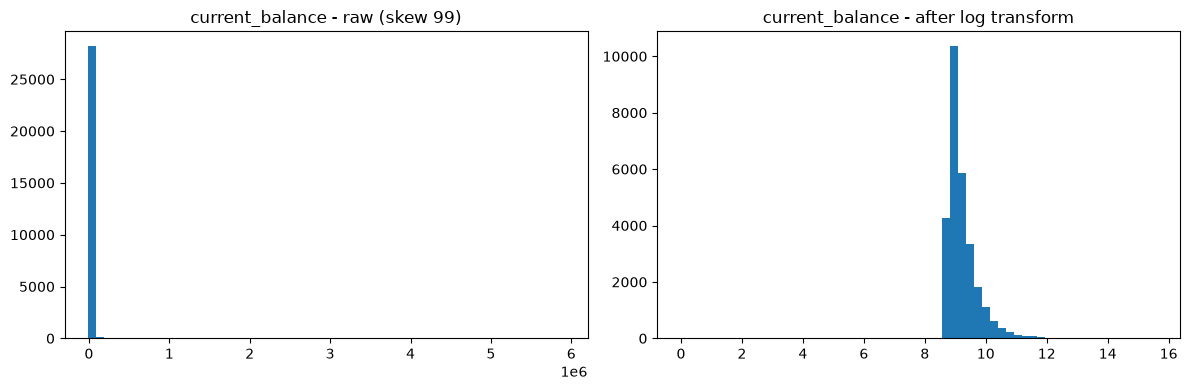

In [95]:
# the money columns, "extremely skewed"
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

clean_df['current_balance'].hist(grid=False, bins=60, ax=axes[0])
axes[0].set_title('current_balance - raw (skew %.0f)' % clean_df['current_balance'].skew())

np.log1p(clean_df['current_balance'] - clean_df['current_balance'].min()).hist(grid=False, bins=60, ax=axes[1])
axes[1].set_title('current_balance - after log transform')

plt.tight_layout()
plt.show()

The raw histogram is a single bar, every customer is crushed into the
first bar because one customer holds 5.9 million. After a log transform the distribution
becomes readabe. This is the justification for log-transforming
the money columns rather than deleting the large values.

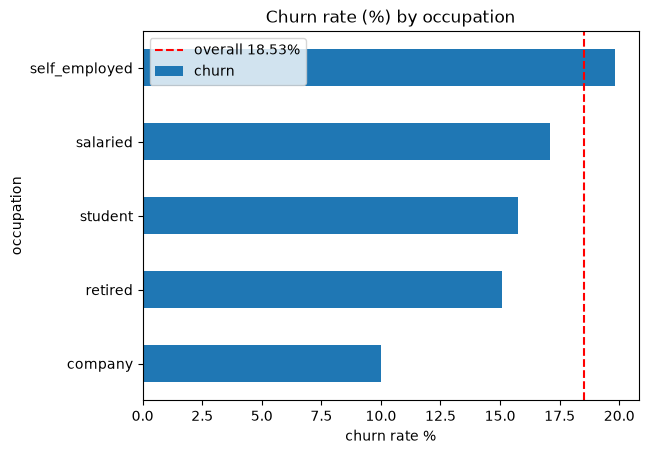

In [96]:
# churn rate by occupation
occ = clean_df.groupby('occupation')['churn'].mean().sort_values() * 100
occ.plot(kind='barh', title='Churn rate (%) by occupation')
plt.axvline(clean_df['churn'].mean()*100, color='red', linestyle='--', label='overall 18.53%')
plt.xlabel('churn rate %')
plt.legend()
plt.show()

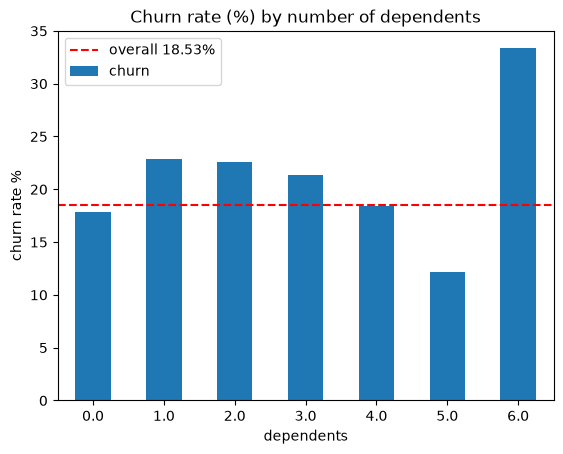

In [97]:
# churn rate by number of dependents
dep = clean_df.groupby('dependents')['churn'].mean() * 100
dep.plot(kind='bar', rot=0, title='Churn rate (%) by number of dependents')
plt.axhline(clean_df['churn'].mean()*100, color='red', linestyle='--', label='overall 18.53%')
plt.ylabel('churn rate %')
plt.legend()
plt.show()

In [100]:
# and by net-worth category
clean_df.groupby('customer_nw_category')['churn'].agg('mean').round(4)

customer_nw_category
1    0.1913
2    0.1790
3    0.1922
Name: churn, dtype: float64

Instead of averages (which the outliers destroy), compare the **median** money values of
churners against customers who stayed.

In [101]:
money_cols = ['current_balance', 'previous_month_end_balance',
              'average_monthly_balance_prevQ', 'average_monthly_balance_prevQ2',
              'current_month_credit', 'previous_month_credit',
              'current_month_debit', 'previous_month_debit',
              'current_month_balance', 'previous_month_balance']

clean_df.groupby('churn')[money_cols].median().T.round(1)

churn,0,1
current_balance,3643.1,1540.9
previous_month_end_balance,3457.7,2928.6
average_monthly_balance_prevQ,3507.6,3721.3
average_monthly_balance_prevQ2,3383.4,3206.4
current_month_credit,0.6,0.7
previous_month_credit,0.6,2.5
current_month_debit,22.0,1120.2
previous_month_debit,42.9,837.5
current_month_balance,3610.6,2554.1
previous_month_balance,3426.9,3696.0


| Period | Stayed | Churned | What it means |
| --- | --- | --- | --- |
| `average_monthly_balance_prevQ2` (2 quarters ago) | 3,383 | 3,206 | Almost identical churners looked like everyone else |
| `average_monthly_balance_prevQ` (last quarter) | 3,508 | 3,721 | Churners actually held more money |
| `previous_month_debit` (money out, last month) | 43 | 838 | much higher the withdrawals begin |
| `current_month_debit` (money out, this month) | 22 | 1,120 | much higher the account is being emptied |
| `current_balance` (now) | 3,643 | 1,541 | Balance has collapsed to under half |

Churn is not a sudden event — it is a visible drain that plays out over about two
months. Customers who leave were normal savers a quarter ago. Then they start
withdrawing heavily, and their balance falls off a cliff.

That is exactly what makes this problem predictable, and it tells the retention team
when to act: the moment debits increase, not after the balance is gone.

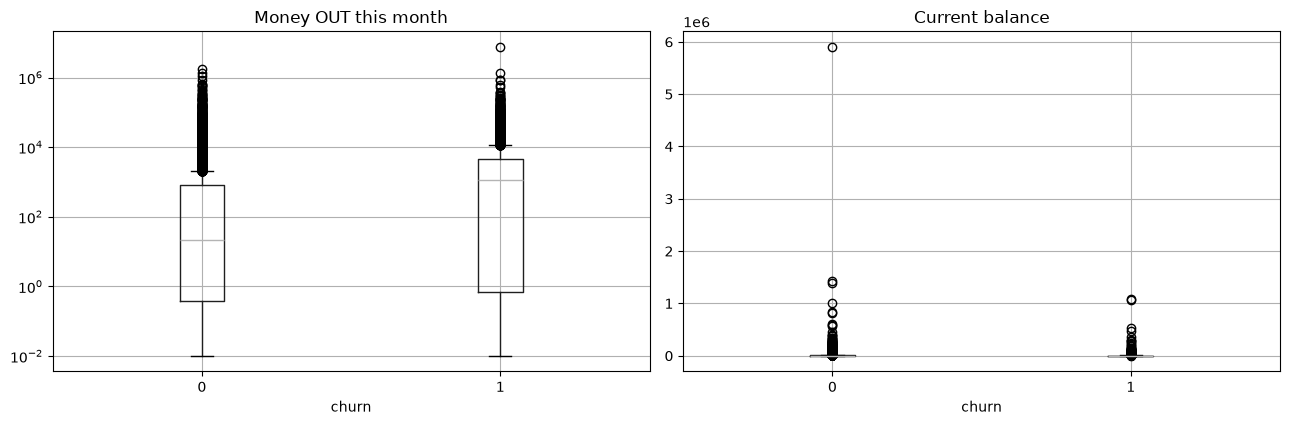

In [102]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

clean_df.boxplot(column='current_month_debit', by='churn', ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Money OUT this month')
axes[0].set_xlabel('churn')

clean_df.boxplot(column='current_balance', by='churn', ax=axes[1])
axes[1].set_title('Current balance')
axes[1].set_xlabel('churn')

plt.suptitle('')
plt.tight_layout()
plt.show()

### Chi-Square test: are the categorical features related to churn?

is the churn rate genuinely different across these
categories, or could the difference be chance?

- p-value < 0.05 : the relationship is statistically significant → keep the feature
- p-value >= 0.05 : the difference could be random → the feature may be droppable

In [108]:
from scipy.stats import chi2_contingency

for col in ['gender', 'occupation', 'customer_nw_category']:
    table = pd.crosstab(clean_df[col], clean_df['churn'])
    chi2, p, dof, expected = chi2_contingency(table)

    result = 'SIGNIFICANT - keep' if p < 0.05 else 'not significant'
    print(f'{col} chi2 = {chi2}   p = {p} : {result}')

gender chi2 = 12.335074671338758   p = 0.0020963923594050585 : SIGNIFICANT - keep
occupation chi2 = 56.95008997367705   p = 1.2673587479192002e-11 : SIGNIFICANT - keep
customer_nw_category chi2 = 7.955973344599787   p = 0.01872329754944543 : SIGNIFICANT - keep


In [ ]:
# So none of the categorical columns should be dropped. 'occupation' is the most useful of the three.

### Correlation matrix — the continuous features

In [111]:
# drop the ID-style columns first, a correlation on a branch or city code is meaningless
corr_df = clean_df.drop(columns=['branch_code', 'city'])

corr_with_churn = corr_df.corr(numeric_only=True)['churn']
corr_with_churn.abs().sort_values(ascending=False).round(3)

churn                             1.000
no_last_txn                       0.085
previous_month_debit              0.073
days_since_txn                    0.056
current_month_debit               0.048
previous_month_credit             0.042
dependents                        0.034
age                               0.030
current_balance                   0.024
current_month_credit              0.021
average_monthly_balance_prevQ2    0.018
previous_month_balance            0.015
average_monthly_balance_prevQ     0.012
previous_month_end_balance        0.007
customer_nw_category              0.007
current_month_balance             0.006
vintage                           0.005
Name: churn, dtype: float64

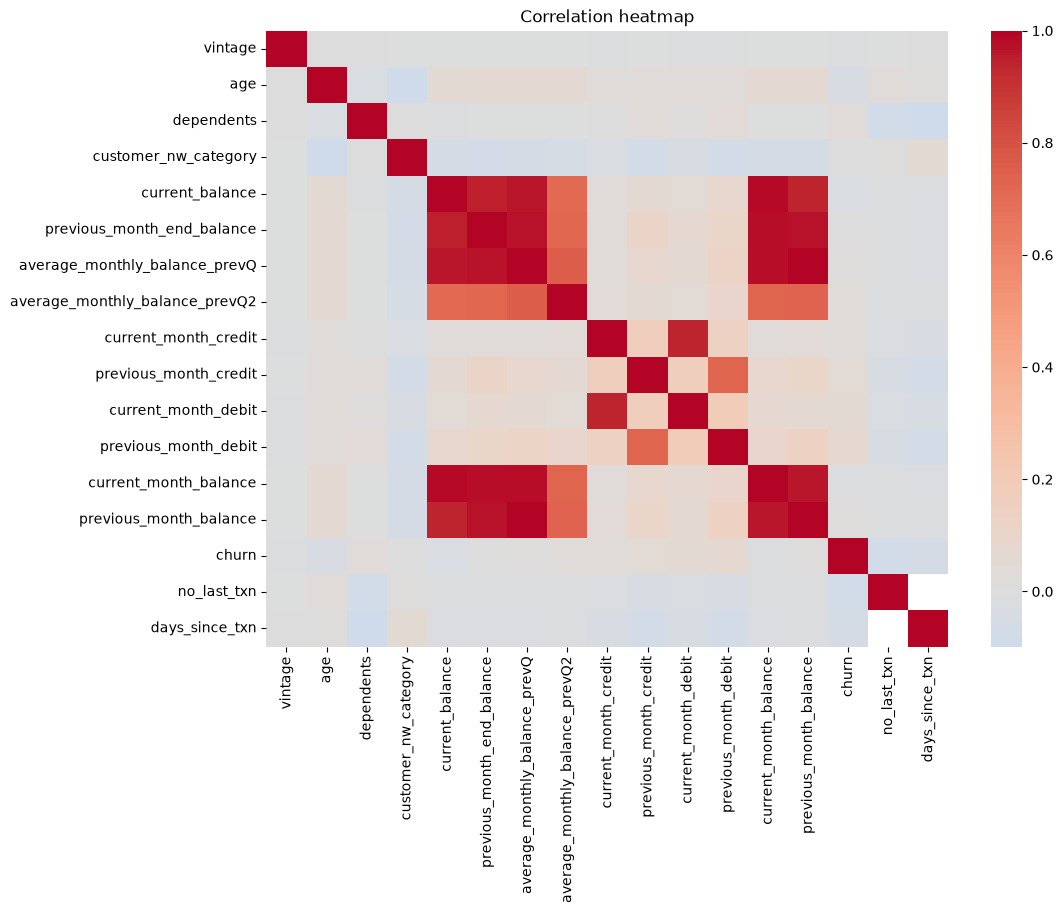

In [112]:
plt.figure(figsize=(11, 8))
sns.heatmap(corr_df.corr(numeric_only=True), cmap='coolwarm', center=0)
plt.title('Correlation heatmap')
plt.show()

### The correlations look so weak, how to fix it?

The strongest correlation with 'churn' is only 0.073.
Log-transforming first fixes this:

In [121]:
# same columns, same target, only the scale changes
print(f'{"column"}                       {"raw"}       {"logged"}')
for col in ['previous_month_debit', 'current_month_debit', 'current_balance']:
    raw = clean_df[col].corr(clean_df['churn'])
    logged = np.log1p(clean_df[col] - clean_df[col].min()).corr(clean_df['churn'])
    print(f'{col:26s} {raw:+8.3f} {logged:+8.3f}')

column                       raw       logged
previous_month_debit         +0.073   +0.200
current_month_debit          +0.048   +0.236
current_balance              -0.024   -0.182


In [125]:
# lets find pairs of money columns that are almost the same thing
cm = clean_df[money_cols].corr().abs()

for i, a in enumerate(money_cols):
    for b in money_cols[i+1:]:
        if cm.loc[a, b] > 0.94:
            print(f'{cm.loc[a, b]:.3f}   {a}  :  {b}')

0.947   current_balance  :  previous_month_end_balance
0.958   current_balance  :  average_monthly_balance_prevQ
0.983   current_balance  :  current_month_balance
0.942   current_balance  :  previous_month_balance
0.971   previous_month_end_balance  :  average_monthly_balance_prevQ
0.975   previous_month_end_balance  :  current_month_balance
0.970   previous_month_end_balance  :  previous_month_balance
0.976   average_monthly_balance_prevQ  :  current_month_balance
0.994   average_monthly_balance_prevQ  :  previous_month_balance
0.963   current_month_balance  :  previous_month_balance


The six balance columns are near-duplicates of each other — the worst pair (`average_monthly_balance_prevQ` and `previous_month_balance`) correlates at **0.994**.

They are all measuring the same quantity at slightly different times. Keeping all six adds
no information but makes a linear model unstable.

My plan is to keep one or two balance columns and replace the rest with derived features that
capture the change — which is where the actual signal lives.

In [127]:
# count outliers using the IQR rule
for col in money_cols:
    Q1 = clean_df[col].quantile(0.25)
    Q3 = clean_df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = clean_df[(clean_df[col] < Q1 - 1.5*IQR) | (clean_df[col] > Q3 + 1.5*IQR)]
    print(f'{col} {len(outliers)} ({len(outliers)/len(clean_df)*100}%)')

current_balance 2739 (9.650482700303009%)
previous_month_end_balance 2731 (9.622295821295188%)
average_monthly_balance_prevQ 2727 (9.608202381791276%)
average_monthly_balance_prevQ2 2612 (9.203015996053837%)
current_month_credit 4558 (16.059474314706502%)
previous_month_credit 4682 (16.496370939327743%)
current_month_debit 3935 (13.864421111972378%)
previous_month_debit 4075 (14.35769149460926%)
current_month_balance 2697 (9.502501585511943%)
previous_month_balance 2720 (9.583538862659433%)


In [130]:
# negative balances, are these errors?
for col in ['current_balance', 'previous_month_end_balance', 'current_month_balance']:
    print(f'{col} negatives: {(clean_df[col] < 0).sum()}   min: {clean_df[col].min()}')

current_balance negatives: 17   min: -5503.96
previous_month_end_balance negatives: 13   min: -3149.57
current_month_balance negatives: 9   min: -3374.18


### Decision: transform, do not delete

| Issue | Decision |
| --- | --- |
| Skewed money columns | Keep and log-transform. Deleting them would remove many customers, including the highest-value ones |
| Negative balances | Keep. These are genuine overdrafts and may themselves signal distress. |
| Impossible ages | Already fixed — imputed with the median. |
| 'dependents' up to 52 | Already capped at 6. |

# Data Preprocessing & Feature Engineering
Transforming, encoding, standardization and preparing features
- **You only need to outline your approach here. No need to execute**

## 1. Feature Engineering — the priority

The EDA showed the raw columns are weak on their own (best correlation **0.073**), but
that churn is a **two-month drain**: debits spike, then the balance collapses. The raw
columns describe *levels*; the signal lives in the *change*. So I build features that
measure movement.

| New feature | Formula | Why |
| --- | --- | --- |
| `balance_change` | `current_balance - previous_month_end_balance` | Direct measure of money leaving |
| `balance_drop_pct` | `(current_balance - avg_balance_prevQ) / avg_balance_prevQ` | How far the balance has fallen **relative to the customer's own normal** — a 1,000 drop means very different things for a small and a large account |
| `quarter_decline` | `avg_monthly_balance_prevQ - avg_monthly_balance_prevQ2` | Is the decline already visible a quarter back? |
| `net_flow_current` | `current_month_credit - current_month_debit` | Net money in or out this month |
| `net_flow_previous` | `previous_month_credit - previous_month_debit` | Same for last month |
| `debit_to_balance` | `current_month_debit / previous_month_end_balance` | Withdrawing 500 from a 600 balance is very different from 500 out of 50,000 |
| `no_last_txn` | already built | Missing transaction date |
| `days_since_txn` | already built | Recency of last activity |

## 2. Handling the high-cardinality columns

`branch_code` (3,185 values) and `city` (1,605 values) cannot be one-hot encoded, that
would create ~4,800 columns.

**Plan (in order of preference):**
1. **Frequency encoding**, replace each code with how often it appears. Keeps the column
   as one number and lets the model learn "big branch vs small branch."
2. **Group the rare codes**, keep the top ~20 branches and bucket the rest as `'other'`,
   then one-hot the result.
3. **Drop them** if neither adds value once tested.

## 3. Encoding the categorical features

Chi-Square confirmed all three categoricals matter, so all three are kept.

| Column | Levels | Method | Why |
| --- | --- | --- | --- |
| `occupation` | 5 | `OneHotEncoder(drop='first')` | No natural order between jobs |
| `gender` | 3 (incl. `unknown`) | `OneHotEncoder(drop='first')` | No order |
| `customer_nw_category` | 3 | keep as-is / `OrdinalEncoder` | Already numeric and ordered |

## 4. Transformations and scaling

**Log-transform the money columns first.** The EDA proved this recovers hidden signal,
`current_month_debit` went from a correlation of 0.048 to **0.236** after logging. Because
some balances are negative (real overdrafts), we cannot use plain `log`; we will use
either `np.log1p(x - min)` or `PowerTransformer(method='yeo-johnson')`, which handles zero
and negative values.

**Then scale.** Logistic regression and any distance-based model need features on a
comparable scale. `StandardScaler` on the numeric columns.

**Drop the redundant balance columns.** Six balance columns correlate up to **0.994** with
each other. We keep one or two levels plus the engineered change features, rather than
feeding the model six copies of the same information.

## 5. Handling the class imbalance

18.53% churn means the model can score 81.47% accuracy by predicting "nobody churns" — so
this must be handled explicitly. We will test all three approaches and compare, exactly as
in the class lesson.

| Approach | What it changes |
| --- | --- |
| `class_weight='balanced'` | The **penalty** — a churner counts more than a stayer |
| **SMOTE** | The **rows** — creates synthetic churner examples |
| **RandomOverSampler** | The **rows** — duplicates existing churners |
| **Threshold tuning** | The cut-off applied to `predict_proba` |

## 6. The preprocessing pipeline

all of the above goes into a single
`ColumnTransformer` so that nothing leaks from test into train:

```
ColumnTransformer
├── numeric, roughly normal   -> SimpleImputer(median) + StandardScaler
├── numeric, heavily skewed   -> SimpleImputer(median) + PowerTransformer(yeo-johnson)
└── categorical (nominal)     -> SimpleImputer(most_frequent) + OneHotEncoder(drop='first')
```

Wrapped in a `Pipeline` with the model at the end, so `GridSearchCV` re-fits the whole
chain inside every cross-validation fold.

# Modelling Approach
What are the models you are planning to build for your capstone.
- **You only need to outline your approach here. No need to execute**

## Model plan: 3 models x 2 versions = 6 models total

Step 1 — Research metric benchmarks. Before building anything, I must find what counts as a
good result for bank churn prediction in published work, so we can judge our own numbers
against something real instead of guessing.

Step 2 — Start from the baseline. For a classification problem the baseline strategy is
the most frequent class. Our baseline model predicts "no churn" for every single
customer:

```
DummyClassifier(strategy='most_frequent')
```

That scores 81.47% accuracy but 0.00 recall, it never finds a single churner. This is
the floor every other model has to beat.

### The 6 models

| | Model | Version 1 | Version 2 |
| --- | --- | --- | --- |
| **Model A** | **Logistic Regression** *(our baseline model)* | Base, default settings | Tuned, `GridSearchCV` |
| **Model B** | **Random Forest** | Base, default settings | Tuned, `GridSearchCV` |
| **Model C** | **XGBoost / Gradient Boosting** | Base, default settings | Tuned, `GridSearchCV` |

**3 models x 2 versions = 6 models.** Each base version is run with default settings first,
then tuned, so we can show exactly how much the tuning improved things.

**Why these three, in this order:**

- **Model A — Logistic Regression.** The simplest sensible model and our starting point.
  It is fast, and its coefficients are readable, so we can tell a non-technical audience
  why a customer was flagged ("their debits rose and their balance fell"). If a complex
  model cannot beat this, the complexity is not worth it.
- **Model B — Random Forest.** Handles non-linear patterns and skewed money features
  without needing perfect transformation, and gives `feature_importances_` so we can see
  which features actually drive the prediction.
- **Model C — XGBoost.** Usually the strongest performer on data like this, and
  the most likely candidate for the final deployed model.

## Tuning

Every tuned version uses `GridSearchCV` with **`scoring='recall'`** (not accuracy), and
`cv`.

| Model | Examples of Parameters to tune |
| --- | --- |
| **A, Logistic Regression** | `penalty`, `class_weight` |
| **B, Random Forest** |  `max_depth`, `min_samples_leaf`, `class_weight` |
| **C, XGBoost** | `n_estimators`, `max_depth`, `learning_rate` |

## Evaluation

All 6 models report the same metrics, collected into a single comparison table (build a list of score dictionaries, then
`pd.DataFrame(scores, index=[...])`).

| Metric | Target | Role |
| --- | --- | --- |
| **Recall (churn)** | **>= 0.70** | **Primary**, the business metric. A missed churner costs far more than a wasted call |
| **ROC-AUC** | **>= 0.80** | **Primary**, ranking quality, and unaffected by the imbalance |
| Precision / F1 | monitored | Keeps the retention call list realistic |
| Confusion matrix | — | Shows the real cost: churners missed vs calls wasted |
| Accuracy | reported, not optimised | Included only to show the baseline scores 81.47% |

## Risks and challenges

| Risk | Mitigation |
| --- | --- |
| **Weak raw correlations** (best is only 0.073) | Feature engineering |
| **Imbalance** churners (18.53%) | `class_weight='balanced'`, SMOTE and RandomOverSampler |
| **High cardinality** in `branch_code` (3,185) and `city` (1,605) | Frequency encoding, or group the rare codes into `'other'` |
| **Extreme skew** in the money columns | Log / Yeo-Johnson transform |
| **Multicollinearity**, six balance columns correlate up to 0.994 | Keep one or two levels, replace the rest with change-based features |